In [9]:
from neural_transport.litmodule import NeuralTransport
from neural_transport.datamodule import CarbonDataModule, CarbonDataset

import torch

from pathlib import Path

import numpy as np
import xarray as xr

%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
model = NeuralTransport.load_from_checkpoint("/Net/Groups/BGI/work_5/CO2_diffusion/carbonbench/transport_models/carbontracker_lowres/flowmatching_dev/flowmatching_20250908_dev/singlestep/checkpoints/last.ckpt")

In [4]:
model

NeuralTransport(
  (model): FlowMatching(
    (submodel): UNet(
      (enc_stages): ModuleList(
        (0): Sequential(
          (0): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(11, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1-3): 3 x Sequential(
          (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (1): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (2): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1

In [5]:
# data_kwargs

N_GPUS = 1
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_PRED = 32

grid = "latlon5.625"
vertical_levels = "l10"
freq = "6h"

data_kwargs = dict(
    data_path="/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker",
    dataset="carbontracker",
    grid=grid,
    vertical_levels=vertical_levels,
    freq=freq,
    n_timesteps=1,
    batch_size_train=BATCH_SIZE_TRAIN // N_GPUS,
    batch_size_pred=BATCH_SIZE_PRED,
    num_workers=32 * N_GPUS,
    val_rollout_n_timesteps=31,
    target_vars=["co2massmix", "airmass"],
    forcing_vars=[
        "gph_bottom",
        "gph_top",
        "p_bottom",
        "p_top",
        "q",
        "t",
        "u",
        "v",
        "blh",
        "cell_area",
        "co2flux_anthro",
        "co2flux_land",
        "co2flux_ocean",
        "orography",
        "tisr",
    ],
    compute=False,
    # time_interval=["1990-01-01", "2014-12-31"],
)

In [10]:
# lit_module_kwargs

from neural_transport.datasets.grids import (
    LATLON_PROTOTYPE_COORDS,
    VERTICAL_LAYERS_PROTOTYPE_COORDS,
)
from neural_transport.models.wrappers_registry import MODELWRAPPERS

TARGET_VARS = ["co2massmix"]
# Uncomment for conditional Flow Matching
FORCING_VARS_1D = [
    # "flow_time"
]
FORCING_VARS_2D = [
    # "blh",
    # "cell_area",
    # "co2flux_anthro",
    # "co2flux_land",
    # "co2flux_ocean",
    # "orography",
    # "tisr",
]
FORCING_VARS_3D = [
    # "airmass",
    # "gph_bottom",
    # "gph_top",
    # "p_bottom",
    # "p_top",
    # "q",
    # "t",
    # "u",
    # "v",
]
grid = "latlon5.625"
vertical_levels = "l10"
freq = "6h"

nlev = len(VERTICAL_LAYERS_PROTOTYPE_COORDS[vertical_levels]["level"])

FORCING_VARS = FORCING_VARS_1D + FORCING_VARS_2D + FORCING_VARS_3D
LEN_ALL_TARGET_VARS = nlev * len(TARGET_VARS)
LEN_ALL_FORCING_VARS = len(FORCING_VARS_1D) + len(FORCING_VARS_2D) + nlev * len(FORCING_VARS_3D)
LEN_ALL_VARS = LEN_ALL_TARGET_VARS + LEN_ALL_FORCING_VARS

lat = LATLON_PROTOTYPE_COORDS[grid]["lat"]
lon = LATLON_PROTOTYPE_COORDS[grid]["lon"]

cos_lat = np.cos(np.radians(lat))[:, None, None].repeat(len(lon), axis=1).reshape(-1, 1)
cos_lat = cos_lat / np.mean(cos_lat)

ds_stats = xr.open_zarr(
    f"/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/train/carbontracker_{grid}_{vertical_levels}_{freq}_stats.zarr"
).compute()

inv_std = {
    k: 1
    / (ds_stats[f"{k}_delta"].sel(stats="std").where(lambda x: x > 1e-14, 1).values)
    ** 2
    for k in TARGET_VARS  # CARBOSCOPE_CARBON3D_VARS
}

weights = {k: cos_lat * inv_std[k] for k in inv_std}

LOSS_WEIGHTS = {k: (10 * v / LEN_ALL_TARGET_VARS) for k, v in weights.items()}

METRIC_WEIGHTS = {f"{k}_delta": cos_lat for k in TARGET_VARS}


MODEL_DIMS = {
    "XS": dict(embed_dim=64),
    "S": dict(embed_dim=128),
    "M": dict(embed_dim=256),
    "L": dict(embed_dim=512),
    "XL": dict(embed_dim=1024),
}

MODEL_SIZE = "S"

regulargrid_kwargs = dict( # for RegularGridModel
    input_vars=TARGET_VARS + FORCING_VARS,
    target_vars=TARGET_VARS,
    nlat=len(lat),
    nlon=len(lon),
    predict_delta=False,
    add_surfflux=False,
    dt=60 * 60 * 6,
    massfixer="",
    targshift=True,
)

wrapper_kwargs = dict( # for RegularGridModel (FlowMatching)
    **regulargrid_kwargs,
    model_kwargs=dict( # for FlowMatching
        submodel="unet",
        model_kwargs=dict( # for RegularGridModel (UNet)
            **regulargrid_kwargs,
            model_kwargs=dict( # for UNet
                in_chans=LEN_ALL_VARS + 1, # + 1 for flow_time
                out_chans=LEN_ALL_TARGET_VARS,
                embed_dim=MODEL_DIMS[MODEL_SIZE]["embed_dim"],
                act="leakyrelu",
                norm="batch",
                enc_filters=[[7], [3, 3], [3, 3], [3, 3]],
                dec_filters=[[3, 3], [3, 3], [3, 3], [3, 3]],
                in_interpolation="bilinear",
                out_interpolation="nearest-exact",
                out_clip=None,
            ),
        ),
        return_intermediates=True,
        method="midpoint",  # 'midpoint' or 'euler'
        nlev=nlev,
        step_size=0.1,
    ),
)

flow = MODELWRAPPERS["flowmatching"](**wrapper_kwargs)

lit_module_kwargs = dict(
    model=flow,
    model_kwargs=wrapper_kwargs["model_kwargs"],
    loss="mse",
    loss_kwargs=dict(
        weights=LOSS_WEIGHTS, spectral_power_weight=0.0, nlat=len(lat), nlon=len(lon), normalize_batch=True,
    ),
    metrics=[
        dict(name=m, kwargs=dict(weights=METRIC_WEIGHTS))
        for m in ["rmse", "r2", "nse", "rabsbias", "rrmse"]
    ],
    # + [dict(name="mass_rmsev2", kwargs=dict(molecule=m)) for m in ["co2"]],
    no_grad_step_shedule=None,
    lr=1e-3,
    weight_decay=0.1,
    lr_shedule_kwargs=dict(
        warmup_steps=1000, halfcosine_steps=99000, min_lr=3e-7, max_lr=1.0
    ),
    val_dataloader_names=["singlestep"],
    plot_kwargs=dict(
        variables=["co2molemix"],
        layer_idxs=[0, 3, 5, 8],
        n_samples=2,
        dataset="carbontracker",
        grid=grid,
        vertical_levels=vertical_levels,
        max_workers=32,
    ),
)

In [11]:
dset = CarbonDataModule(**data_kwargs)
dset.setup("fit")

In [12]:
dl_val = dset.val_dataloader()
batch_val = next(iter(dl_val[0]))
batch_val = {k: v.squeeze(1) if isinstance(v, torch.Tensor) else v for k, v in batch_val.items()}

In [13]:
model.to(device="cpu")
model.train()

NeuralTransport(
  (model): FlowMatching(
    (submodel): UNet(
      (enc_stages): ModuleList(
        (0): Sequential(
          (0): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(11, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1-3): 3 x Sequential(
          (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (1): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (2): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1

In [14]:
preds = model.model(batch_val)

In [15]:
f"Predictions: Standard Deviation {preds['co2massmix'].std()}, Mean {preds['co2massmix'].mean()}"

'Predictions: Standard Deviation 0.8087321519851685, Mean 0.009945088066160679'

In [16]:
batch_val["co2massmix_next"].std(), batch_val["co2massmix_next"].mean()

(tensor(8.3530), tensor(614.3007))

In [17]:
batch_normalized = {}
for v in preds:
    for suffix in ['', '_next']:
        key = f"{v}{suffix}"
        if key in batch_val:
            mean = batch_val[f"{v}_offset"]
            std = batch_val[f"{v}_scale"]
            x_in_curr = (batch_val[key] - mean) / std
            batch_normalized[key] = x_in_curr

In [18]:
f'Batch: Standard Deviation: {batch_normalized["co2massmix_next"].std()}, Mean: {batch_normalized["co2massmix_next"].mean()}'

'Batch: Standard Deviation: 0.5031848549842834, Mean: 1.8334089517593384'

In [19]:
model.eval()
model.return_intermediates = True

In [20]:
def load_dataset(data_path, data_kwargs):

    dataset = CarbonDataset(
        data_path=data_path,
        dataset=data_kwargs["dataset"],
        grid=data_kwargs["grid"],
        vertical_levels=data_kwargs["vertical_levels"],
        freq=data_kwargs["freq"],
        n_timesteps=1,
        target_vars=data_kwargs["target_vars"],
        forcing_vars=data_kwargs["forcing_vars"],
        load_obspack=True,
        new_zarr=True,
    )

    return dataset

data_path_forecast = Path(
    "/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/test/"
)

dataset = load_dataset(data_path_forecast, data_kwargs)

In [21]:
import importlib
import neural_transport.inference.generative as generative
importlib.reload(generative)

<module 'neural_transport.inference.generative' from '/Net/Groups/BGI/work_5/CO2_diffusion/neural_transport/neural_transport/inference/generative.py'>

In [22]:
outpath = Path("test_preds")
ds_all = generative.iterative_generate(
    model,
    dataset,
    outpath=outpath,
    rollout=False,
    device="cuda",
    zarr_filename=None,
    freq=None,
    zero_surfflux=False,
    remap=False,
    target_vars_3d=["co2massmix"],
    target_vars_2d=[],
    save_obs=False,   # True only possible if "gph_bottom", "gph_top" are in batch
    n_samples=2,   # keep small for a test
)

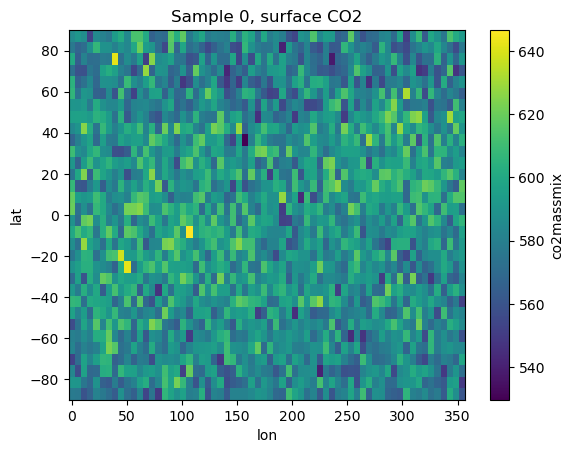

In [23]:
da = ds_all["co2massmix"].isel(sample=0, level=0).compute()
da.plot(
    x="lon", y="lat", cmap="viridis"
)
plt.title("Sample 0, surface CO2")
plt.show()

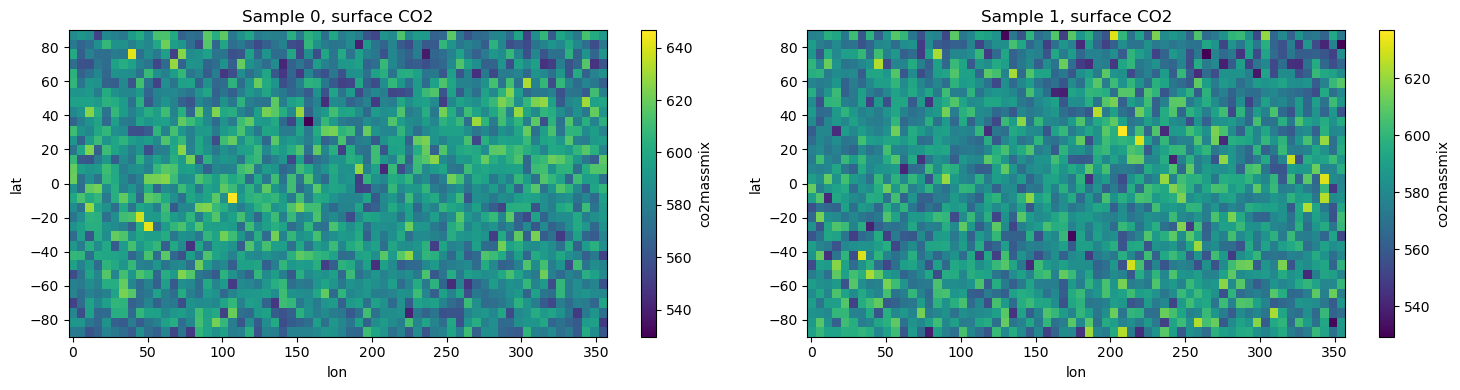

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for i, ax in enumerate(axes):
    da = ds_all["co2massmix"].isel(sample=i, level=0).compute()
    da.plot(
        x="lon", y="lat", ax=ax, cmap="viridis"
    )
    ax.set_title(f"Sample {i}, surface CO2")

plt.tight_layout()
plt.show()


In [29]:
import neural_transport.training.train as train
importlib.reload(train)

<module 'neural_transport.training.train' from '/Net/Groups/BGI/work_5/CO2_diffusion/neural_transport/neural_transport/training/train.py'>

In [36]:
run_dir = Path.cwd()
ckpt = "best"
massfixer = ["scale"]

In [ ]:
train.predict(
        run_dir / "singlestep",
        data_path_forecast,
        data_kwargs,
        device="cuda",
        freq=freq,
        ckpt=ckpt,
        lit_module_kwargs=lit_module_kwargs,
        massfixer=massfixer,
    )

Generating /Net/Groups/BGI/work_5/CO2_diffusion/carbonbench/transport_models/carbontracker_lowres/flowmatching_dev/flowmatching_20250908_dev/singlestep/checkpoints/Epoch=5-Step=2328-LossVal=46.807968.ckpt best CKPT


In [37]:
target_path = (
        data_path_forecast
        / f"{data_kwargs['dataset']}_{data_kwargs['grid']}_{data_kwargs['vertical_levels']}_{data_kwargs['freq']}.zarr"
    )

In [38]:
pred_path = (
        run_dir
        / "singlestep"
        / "preds"
        / f"ckpt={ckpt}_massfixer={massfixer}"
        / f"co2_pred_rollout_{freq}.zarr"
    )

In [40]:
train.score(target_path, pred_path)

ValueError: Dimensions {'time'} do not exist. Expected one or more of ('sample', 'lat', 'lon', 'level')

In [45]:
import multiprocessing

movie_interval=["2018-01-01", "2018-03-31"]
num_workers=multiprocessing.cpu_count() // 2

In [46]:
train.plot(
        target_path,
        pred_path,
        data_path_forecast,
        data_kwargs,
        movie_interval,
        num_workers,
    )

CoordinateValidationError: coordinate time has dimensions ('time',), but these are not a subset of the DataArray dimensions ('sample', 'lat', 'lon', 'level')

In [ ]:
# import shutil
# import tempfile
# import time as pytime
# from pathlib import Path

# import numpy as np
# import pandas as pd
# import torch
# import xarray as xr
# from cdo import Cdo
# from tqdm import tqdm


# def get_zarrpath_obspath(out_path, rollout, freq, zarr_filename=None, zero_surfflux=False):
#     if zarr_filename is None:
#         zarr_filename = (
#             f"co2_pred_rollout_{freq}.zarr" if rollout else "co2_pred_singlestep.zarr"
#         )
#     if zero_surfflux:
#         zarr_filename = zarr_filename.replace("co2_pred", "co2_pred_zeroflux")

#     out_path = Path(out_path)
#     out_path.mkdir(exist_ok=True, parents=True)
#     zarrpath = out_path / zarr_filename

#     obspath = out_path / f"obs_{zarr_filename}"

#     return zarrpath, obspath


# def remap_with_cdo(dataset, prototype_zarr, ds):
#     cdo = Cdo()
#     prototype_zarr.lat.attrs = {
#         "long_name": "latitude",
#         "units": "degrees_north",
#         "standard_name": "latitude",
#     }
#     prototype_zarr.lon.attrs = {
#         "long_name": "longitude",
#         "units": "degrees_east",
#         "standard_name": "longitude",
#     }

#     ds["clon_vertices"] = dataset.grid_ds.clon_vertices
#     ds["clat_vertices"] = dataset.grid_ds.clat_vertices
#     ds["clon"] = dataset.grid_ds.clon
#     ds["clat"] = dataset.grid_ds.clat
#     ds["co2massmix"].attrs = {"CDI_grid_type": "unstructured"}
#     ds["co2density"].attrs = {"CDI_grid_type": "unstructured"}
#     ds["time"].attrs = {"standard_name": "time"}
#     ds["height"].attrs = {"standard_name": "air_pressure"}

#     grid_temp_file = tempfile.NamedTemporaryFile(
#         delete=True, prefix="grid_temp_file_", dir=tempfile.gettempdir()
#     )
#     prototype_zarr.to_netcdf(grid_temp_file.name)

#     ds_temp_file = tempfile.NamedTemporaryFile(
#         delete=True, prefix="ds_temp_file_", dir=tempfile.gettempdir()
#     )
#     ds.transpose("time", "height", "cell", "nv").to_netcdf(ds_temp_file.name)

#     ds_remap = cdo.remapcon(
#         grid_temp_file.name, input=ds_temp_file.name, returnXDataset=True
#     )

#     grid_temp_file.close()
#     ds_temp_file.close()

#     cdo.cleanTempDir()
#     return ds_remap


# def iterative_generate(
#     model,
#     dataset,
#     outpath,
#     rollout=False,
#     device="cuda",
#     zarr_filename=None,
#     freq=None,
#     zero_surfflux=False,
#     remap=False,
#     target_vars_3d=[],
#     target_vars_2d=[],
#     save_obs=True,
#     n_samples=10,
# ):
#     zarrpath, obspath = get_zarrpath_obspath(outpath, rollout, freq, zarr_filename, zero_surfflux = zero_surfflux)

#     prototype_zarr = dataset.create_prototype_zarr(
#         zarrpath,
#         target_vars_3d=target_vars_3d,
#         target_vars_2d=target_vars_2d,
#         grid="default" if remap else None,
#     )

#     model = model.eval().to(device)
#     model.return_intermediates = True

#     dss = []
#     obss = []
#     for i in range(n_samples):
#         batch = {k: v.unsqueeze(0).to(device) for k, v in dataset[0].items()} # condition on the first timestep

#         if zero_surfflux:
#             for var in ["co2flux_anthro", "co2flux_land", "co2flux_ocean"]:
#                 batch[var] = torch.zeros_like(batch[var])

#         with torch.no_grad():
#             preds = model(batch)
#             traj = preds["trajectory"]
#             print({k: v.shape for k, v in preds.items()})
#             print(f"co2massmix: {[v.shape for v in preds['co2massmix']]}")
#             print(f"trajectory: {[v.shape for v in preds['trajectory']]}")
#         ds = xr.Dataset(
#             {k: dataset.tensor_to_xarray(pred) for k, pred in preds.items()}
#         )

#         ds = ds.assign_coords(
#             time=prototype_zarr.time[:traj.shape[-1]],
#             sample=("sample", [i]),
#         )

#         if remap:
#             ds = remap_with_cdo(dataset, prototype_zarr.isel(time=0), ds)

#         if save_obs:
#             obs = dataset.readout_stations(ds, grid="default" if remap else None)
#             obss.append(obs)

#         dss.append(ds)

#     ds_all = xr.concat(dss, dim="sample").fillna({"obs_filename": ""})
#     ds_all.to_zarr(zarrpath, mode="w")

#     if save_obs:
#         obs_all = xr.concat(obss, dim="sample").fillna({"obs_filename": ""})
#         obs_all.to_zarr(obspath, mode="w")

#     return ds_all
        